<a href="https://colab.research.google.com/github/anmollate/Data-Science/blob/main/PowerTransformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Not Needed To Explicitly apply scaling while using power transformers the scaling is default in power transformers such as box-cox and yeo-johnson, box-cox cannot handle 0 and negative values whereas yeo-johnson handles them flawlessly. Both are used to make the data normally distributed.

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [103]:
df=pd.read_csv("/content/drive/MyDrive/Datasets/Concrete Compressive Strength.csv")

In [104]:
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength,water_cement_ratio,total_binder,aggregate_to_cement,cement_water_interaction,age_strength_proxy
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89,1.440188,353.3,12.174719,28754.55,5.291503
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51,0.937235,335.4,11.113019,26736.87,3.741657
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22,0.749597,345.7,7.272371,46850.00,5.291503
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85,0.857140,380.0,6.022534,60648.00,5.291503
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29,1.248700,338.2,11.266723,29922.84,5.291503


In [105]:
df.drop(columns=['water_cement_ratio','total_binder','aggregate_to_cement','cement_water_interaction','age_strength_proxy'],inplace=True)

In [106]:
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


In [107]:
df.isnull().sum()

,0
cement,0
slag,0
ash,0
water,0
superplastic,0
coarseagg,0
fineagg,0
age,0
strength,0


In [108]:
#checking for zero and negative values in the column
df.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [109]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['strength']),df['strength'],test_size=0.2,random_state=42)

In [110]:
#Applying Linear Regression Without Any Transformation
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Accuracy:",r2_score(y_test,y_pred))

Accuracy: 0.6081118525118778


In [111]:
#cross validating the results
lr=LinearRegression()
scores=cross_val_score(lr,df.drop(columns=['strength']),df['strength'],scoring='r2')
print(scores.mean())

0.6012883381757209


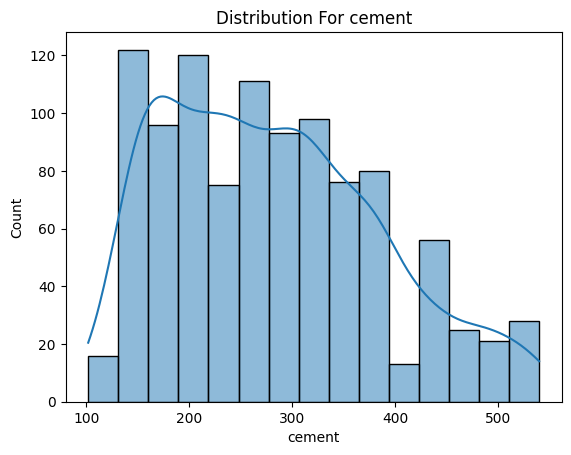

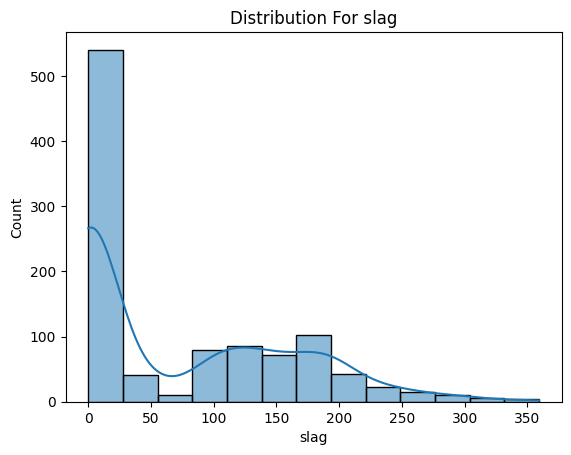

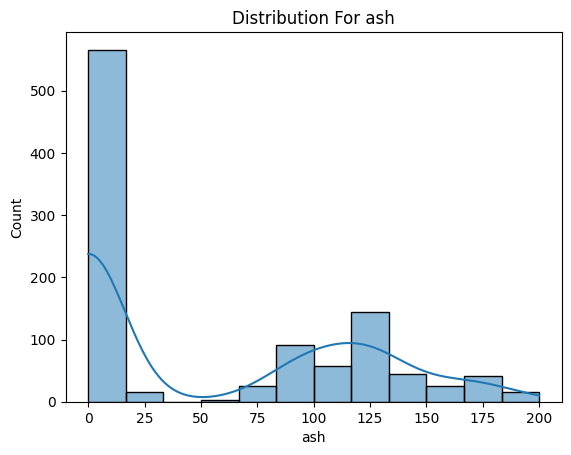

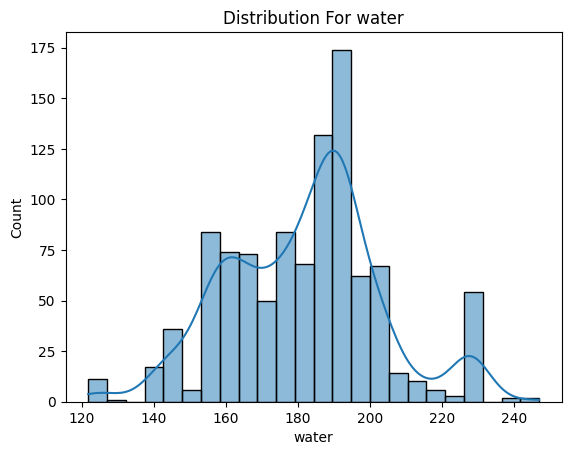

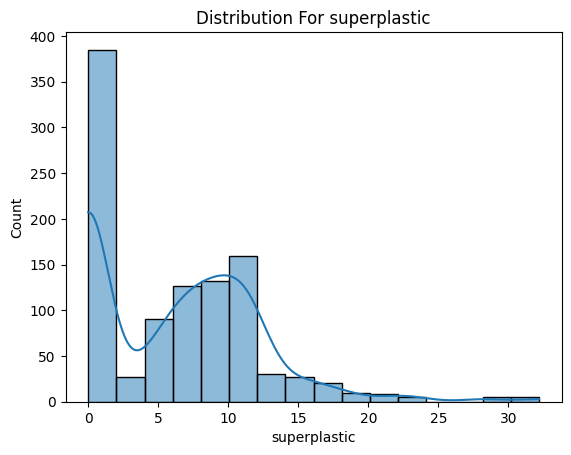

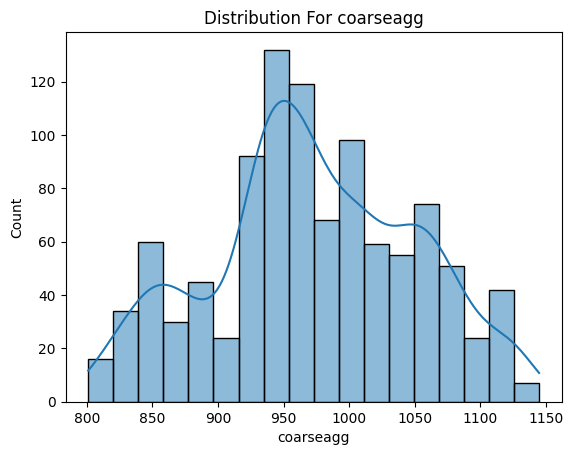

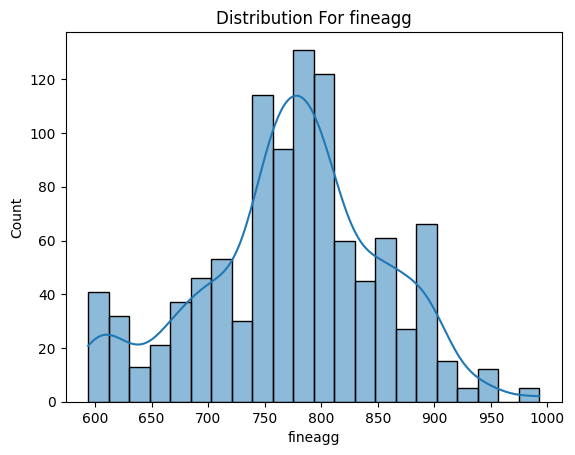

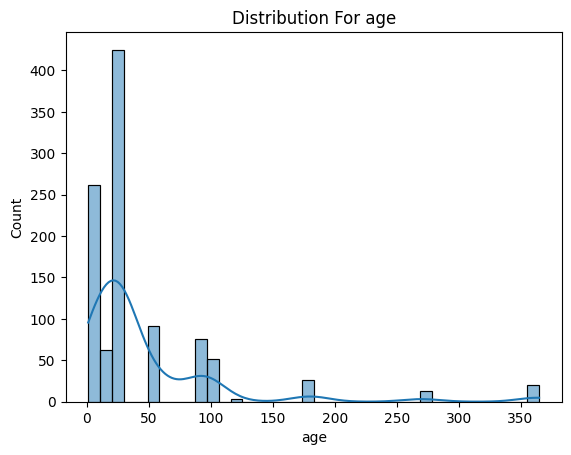

In [112]:
#plotting distribution graphs for each of the columns in dataset
for column in df.drop(columns=['strength']).columns:
  sns.histplot(df[column],kde=True)
  plt.title(f"Distribution For {column}")
  plt.show()
  print()

In [113]:
ptransformer=PowerTransformer(method='box-cox')

In [114]:
x_train_transformed=ptransformer.fit_transform(x_train+0.000001) #adding a small value as box_cox cannot handle zeros
x_test_transformed=ptransformer.transform(x_test+0.000001)

In [115]:
lr2=LinearRegression()
lr2.fit(x_train_transformed,y_train)
y_pred_trans=lr2.predict(x_test_transformed)
print(r2_score(y_test,y_pred_trans))

0.782031754282648


In [116]:
#cross validation
lir=LinearRegression()

X_transformed_combined = pd.DataFrame(np.concatenate([x_train_transformed, x_test_transformed], axis=0), columns=x_train.columns)
y_combined = pd.concat([y_train, y_test], axis=0)

scores2=cross_val_score(lir, X_transformed_combined, y_combined, scoring='r2')
print(scores2.mean())

0.7980289798929988


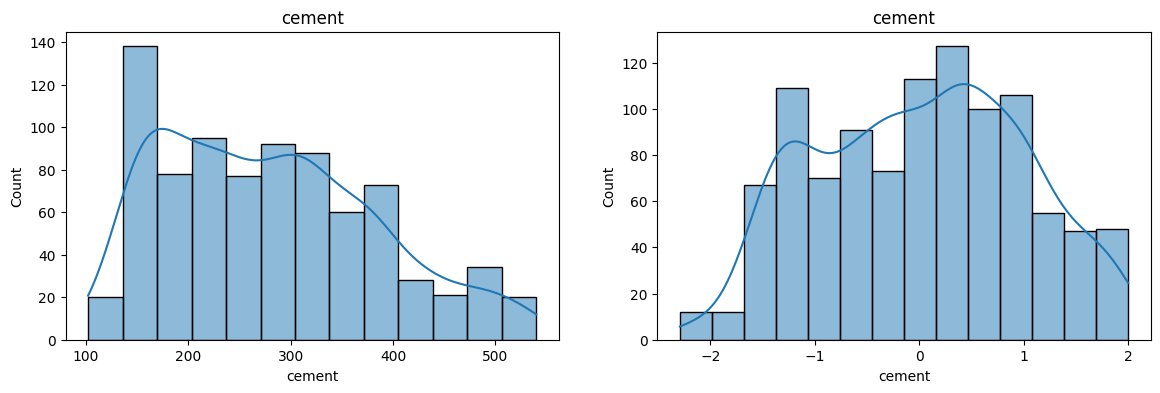

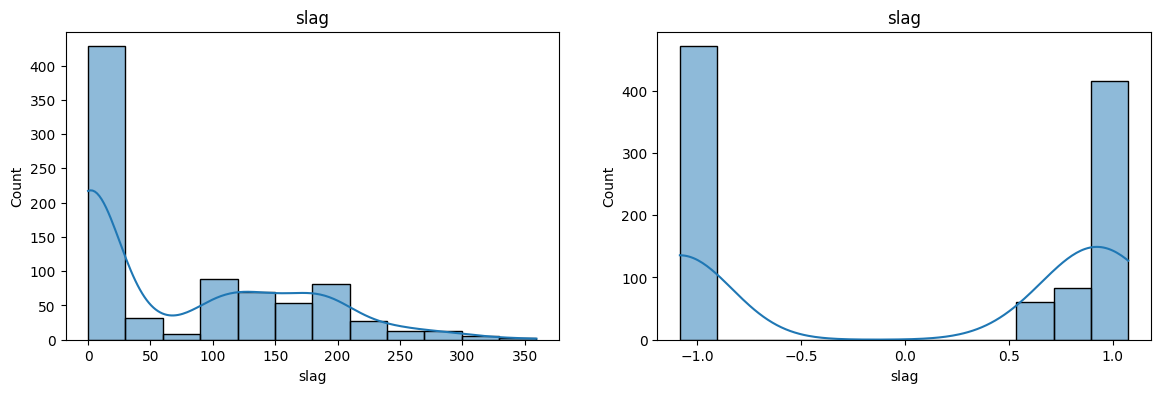

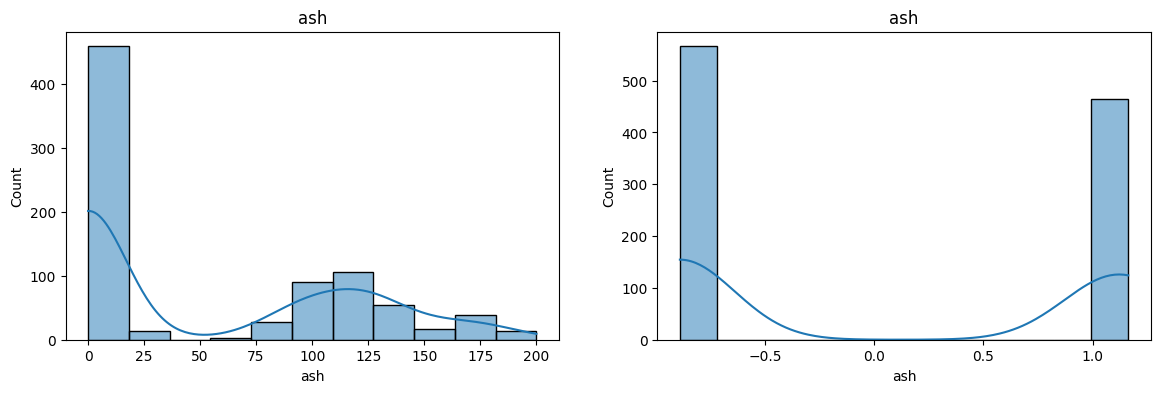

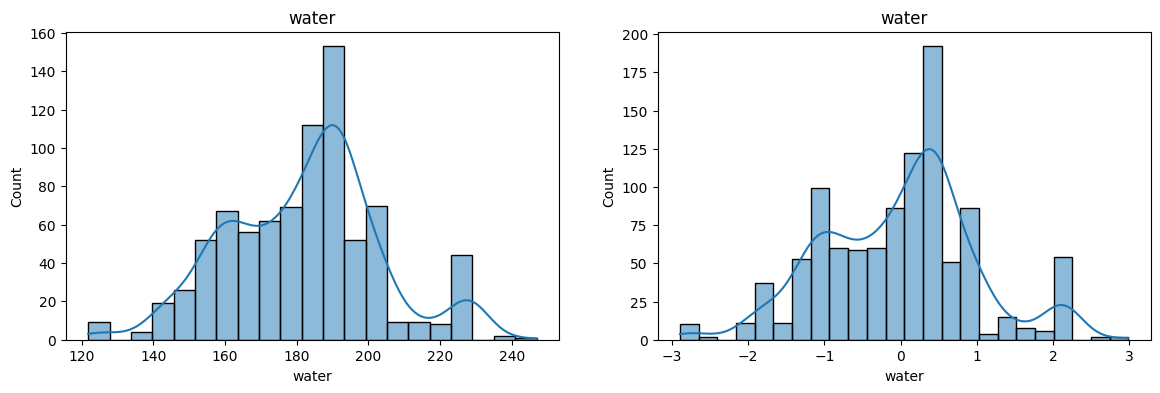

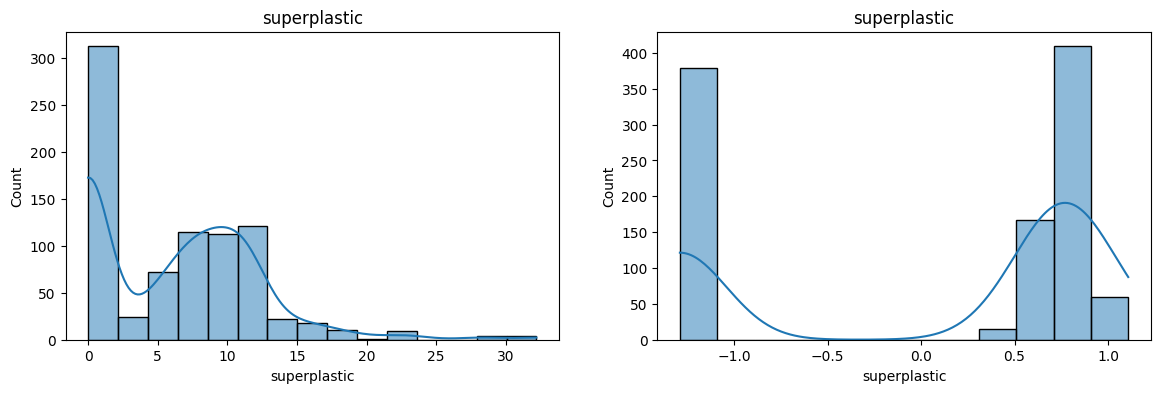

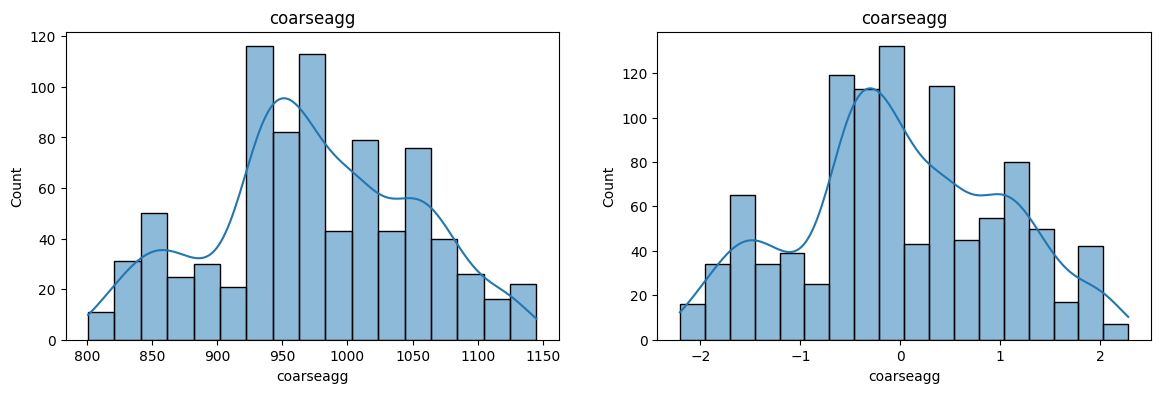

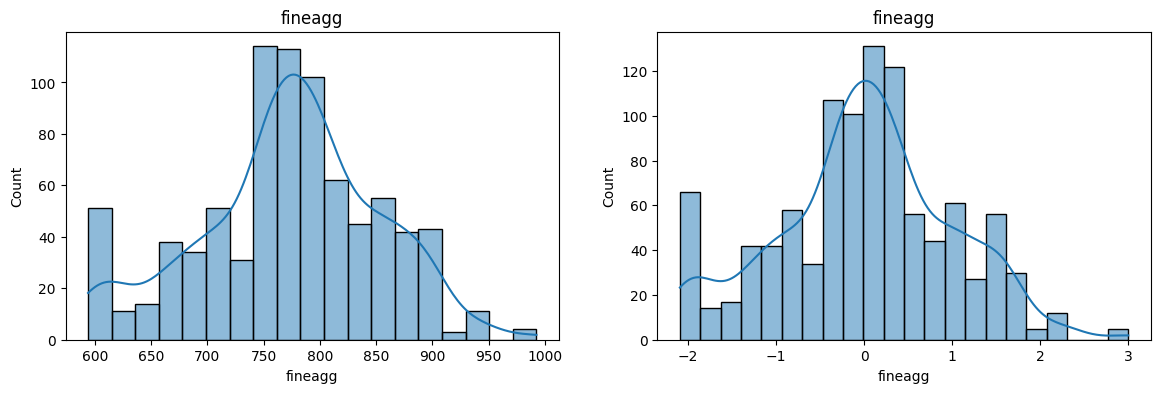

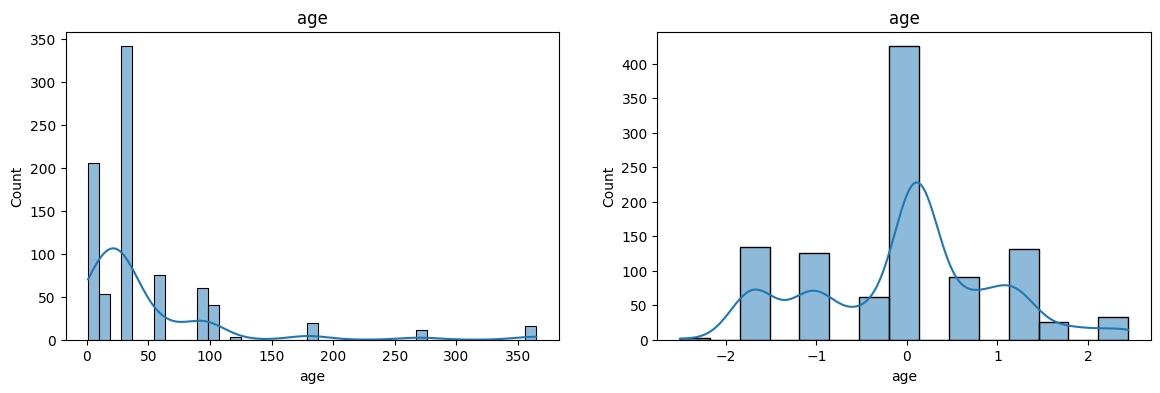

In [117]:
#plotting the graphs for before and after transformation
for column in df.drop(columns=['strength']).columns:
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.histplot(x_train[column],kde=True)
  plt.title(column)

  plt.subplot(122)
  sns.histplot(X_transformed_combined[column],kde=True)
  plt.title(column)
  plt.show()